In [3]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

import keras

In [14]:
# Xa = pandas.read_csv("../conjuntos/titanic_X_train.csv").drop("Unnamed: 0", axis=1)
Xa = pandas.read_csv("../conjuntos/titanic_X_train.csv", index_col=0)
Xb = pandas.read_csv("../conjuntos/titanic_X_test.csv", index_col=0)
Ya = pandas.read_csv("../conjuntos/titanic_Y_train.csv", index_col=0)
Yb = pandas.read_csv("../conjuntos/titanic_Y_test.csv", index_col=0)
Xa

,Sex_female,Age,Pclass2_1ra,Pclass2_2da,Family,Family2_couple,Family2_family,Fare2,Cabin2,Embarked2_C,Embarked2_Q,Embarked2_X
164,0.0,1.0,0.0,0.0,5.0,0.0,1.0,3.705921,0.0,0.0,0.0,0.0
659,0.0,58.0,1.0,0.0,2.0,0.0,1.0,4.738608,1.0,1.0,0.0,0.0
536,0.0,45.0,1.0,0.0,0.0,0.0,0.0,3.316003,1.0,0.0,0.0,0.0
875,1.0,15.0,0.0,0.0,0.0,0.0,0.0,2.107178,0.0,1.0,0.0,0.0
196,0.0,26.0,0.0,0.0,0.0,0.0,0.0,2.169054,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
98,1.0,34.0,0.0,1.0,1.0,1.0,0.0,3.178054,0.0,0.0,0.0,0.0
322,1.0,30.0,0.0,1.0,0.0,0.0,0.0,2.591516,0.0,0.0,1.0,0.0
382,0.0,32.0,0.0,0.0,0.0,0.0,0.0,2.188856,0.0,0.0,0.0,0.0
365,0.0,30.0,0.0,0.0,0.0,0.0,0.0,2.110213,0.0,0.0,0.0,0.0


In [15]:
Xa.shape, Ya.shape

((791, 12), (791, 1))

## Red neuronal de 1 neurona de respuesta cerrada 

> Salida: logística / sigmoide / `sigmoid`

$$
\hat{y} = \phi(z) = \frac{\exp{(z)}}{1 + \exp{(z)}}
$$

> Pérdida: Entropía cruzada binaria

$$
L = -y \ln{(y - \varepsilon)} - (1 - y) \ln{(1 - y + \varepsilon)}
$$

> Optimizador:

* `SGD` - Descenso del Grandiente Estocástico (*Stochastic Gradient Descend*)
* `ADAM` - Descenso del Gradiente con Momento Adaptativo

In [91]:
modelo = keras.Sequential([
    keras.Input(shape=(12,)), # Entrada
    keras.layers.Dense(1, activation="sigmoid"), # Salida
])

modelo.compile(
    optimizer="adam", # lineal - sgd / logístico - adam
    loss="binary_crossentropy", # lineal - mse / logístico - binary_crossentropy
    metrics=["accuracy"], # lineal - mae / logístico - accuracy
)

modelo.summary() # Parámetros de aprendizaje

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

### Fase de entrenamiento

1. Datos de entrenamiento ($X_{train}$, $Y_{train}$)
2. Épocas o iteraciones de refuerzo
3. Tamaño de lote (aprendizaje en trozos)
4. Historial de entramiento (graficar el error) 

In [92]:
historial = modelo.fit(Xa, Ya, epochs=200)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3694 - loss: 13.1835  
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - accuracy: 0.3873 - loss: 12.8049
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3631 - loss: 12.4679 
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3891 - loss: 11.6521 
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step - accuracy: 0.3559 - loss: 11.4016
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - accuracy: 0.3949 - loss: 10.3433
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step - accuracy: 0.3907 - loss: 10.0552
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step - accuracy: 0.3853 - loss: 9.2619
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - accuracy: 0.3866 - loss: 8.9549
Epoch 10/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - accuracy: 0.3839 - loss: 8.2613
Epoch 11/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - accuracy: 0.3838 - loss: 7.6934
Epoch 12/200
25/25 ━━━━━━━━━━━━━━━━━

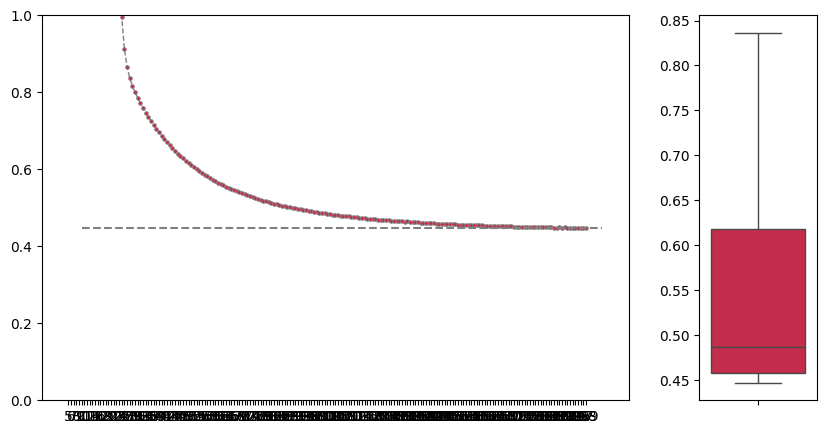

In [100]:
figure, axes = pyplot.subplots(1, 2, figsize=(10, 5), width_ratios=(5, 1))

seaborn.pointplot(x=historial.epoch[5:], y=historial.history["loss"][5:], ax=axes[0], 
                  linestyle="--", linewidth=1, color="gray", marker="o", markerfacecolor="crimson")
axes[0].hlines(pandas.Series(historial.history["loss"][5:]).quantile(0.05), 5, 200, 
               linestyle="--", color="gray")
axes[0].set_ylim(0, 1)
seaborn.boxplot(y=historial.history["loss"], ax=axes[1],
                showfliers=False, color="crimson")
pyplot.show()

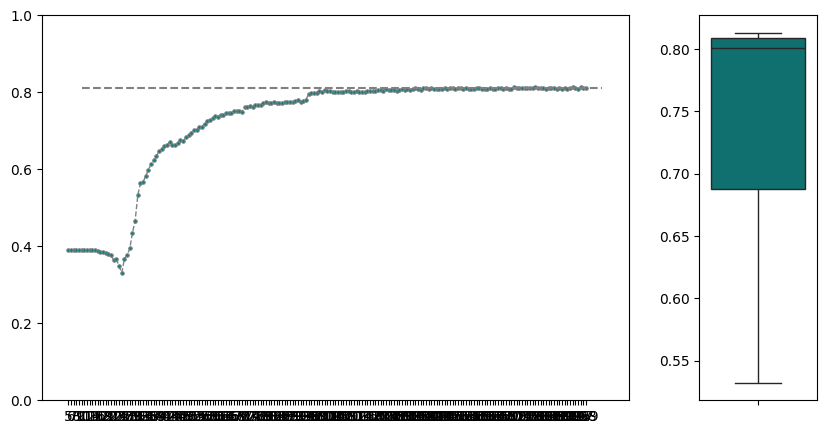

In [ ]:
figure, axes = pyplot.subplots(1, 2, figsize=(10, 5), width_ratios=(5, 1))

seaborn.pointplot(x=historial.epoch[5:], y=historial.history["accuracy"][5:], ax=axes[0], 
                  linestyle="--", linewidth=1, color="gray", marker="o", markerfacecolor="teal")
axes[0].hlines(pandas.Series(historial.history["accuracy"][5:]).quantile(0.95), 5, 200, 
               linestyle="--", color="gray")
axes[0].set_ylim(0, 1)
seaborn.boxplot(y=historial.history["accuracy"], ax=axes[1],
                showfliers=False, color="teal")
pyplot.show()

## Valición de la red neuronal

> Poner a prueba los datos de valición ($X_{test}$)

In [123]:
Yp = modelo.predict(Xb).flatten()

P1 = pandas.DataFrame({
    "Y_real": Yb.values.flatten(),
    "Y_predict": Yp,
})

P1

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,Y_real,Y_predict
0,1,0.799045
1,0,0.160636
2,0,0.616678
3,0,0.236113
4,0,0.172496
...,...,...
95,0,0.327100
96,1,0.958719
97,1,0.918081
98,0,0.111598


<Axes: xlabel='Y_real', ylabel='Y_predict'>

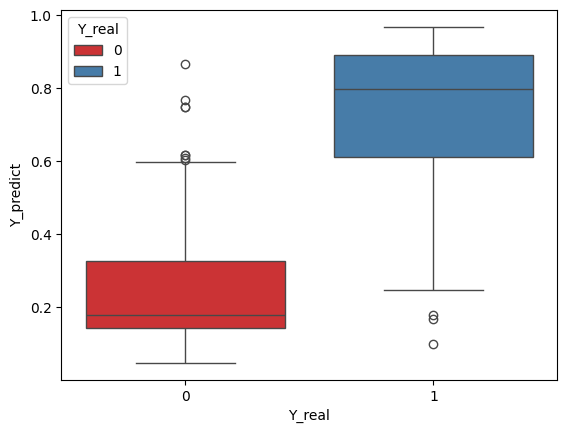

In [124]:
seaborn.boxplot(x=P1["Y_real"], y=P1["Y_predict"], hue=P1["Y_real"], palette="Set1")

<Axes: xlabel='Y_real', ylabel='Y_predict'>

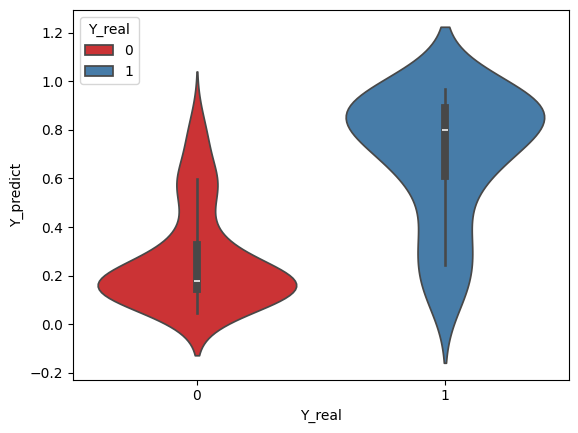

In [125]:
seaborn.violinplot(x=P1["Y_real"], y=P1["Y_predict"], hue=P1["Y_real"], palette="Set1")

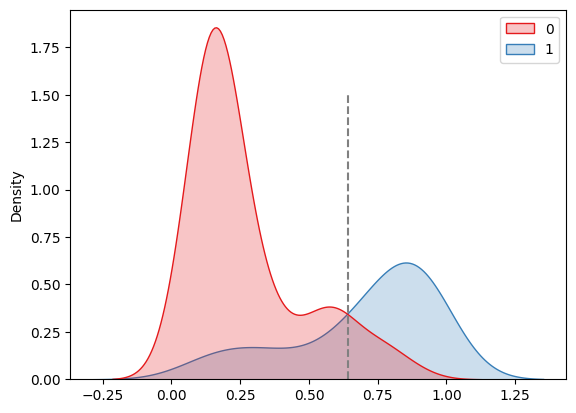

In [137]:
seaborn.kdeplot(x=Yp, hue=Yb.values.flatten(), fill=True, palette="Set1")
pyplot.vlines(0.642, 0, 1.5, linestyle="--", color="gray")

In [143]:
Yb.values.flatten()

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1])

Exactitud (accuray): 87.00%
Precisión (precision): 86.21%
Sensibilidad (sensitivity): 73.53%
Especificidad (specificity): 93.94%
Predicción negativa (negative-predict-value): 87.32%
F1 (f1-score): 89.91%


<Axes: >

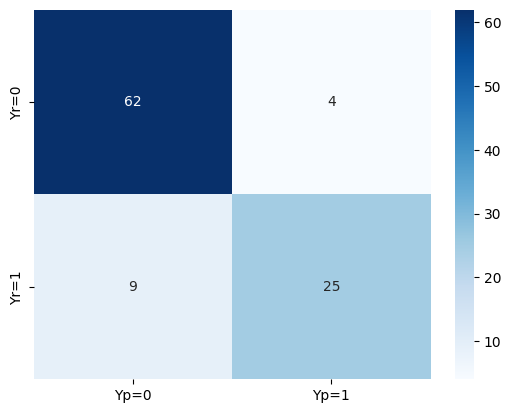

In [164]:
from sklearn import metrics

umbral = 0.642 # Óptimo visual: 0.642, Éstandar: 0.5, Otros: 0.2, 0.8

tn, fp, fn, tp = metrics.confusion_matrix(Yb.values.flatten(), Yp > umbral).flatten()

# Credibilidad en general
accuracy = (tn + tp) / (tn + fp + fn + tp)
print(f"Exactitud (accuray): {100 * accuracy:.2f}%")
# Credibilidad para decir la verdad (cuánto creer si dice 1 y era 1)
precision = tp / (tp + fp)
print(f"Precisión (precision): {100 * precision:.2f}%")
# Credibilidad para no mentir (cuánto creer si dice 1 y era 0)
sensitivity = tp / (tp + fn)
print(f"Sensibilidad (sensitivity): {100 * sensitivity:.2f}%")
# Credibilidad para no mentir en forma contraria (cuánto creer si dice 0 y era 1)
specificity = tn / (tn + fp)
print(f"Especificidad (specificity): {100 * specificity:.2f}%")
# Credibilidad para decir la verdad en forma contraria (cuánto creer si dice 0 y era 0)
npv = tn / (tn + fn)
print(f"Predicción negativa (negative-predict-value): {100 * npv:.2f}%")
# Credibilidad balanceada entre decir la verdad y no mentir (de forma positiva)
f1 = 2 * (precision * specificity) / (precision + specificity)
print(f"F1 (f1-score): {100 * f1:.2f}%")

matrix = pandas.DataFrame([
    [tn, fp],
    [fn, tp],
], index=["Yr=0", "Yr=1"], columns=["Yp=0", "Yp=1"])

seaborn.heatmap(matrix, annot=True, cmap="Blues")

## Evaluar la red neuronal con hipótesis o nuevos datos

> Hipótesis: Caso real vs Caso alterado

> Nuevos datos: Observaciones nunca vistas

In [ ]:
# Guardar el modelo de la red neuronal

modelo.save("../modelos/titanic_nn_12i_1o_survived.keras")

In [152]:
modelo = keras.models.load_model("../modelos/titanic_nn_12i_1o_survived.keras")

modelo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (168.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28 (116.00 B)

In [154]:
Xb.iloc[0]

Sex_female        1.000000
Age               1.000000
Pclass2_1ra       0.000000
Pclass2_2da       0.000000
Family            2.000000
Family2_couple    0.000000
Family2_family    1.000000
Fare2             2.495954
Cabin2            0.000000
Embarked2_C       0.000000
Embarked2_Q       0.000000
Embarked2_X       0.000000
Name: 172, dtype: float64

In [ ]:
modelo.predict(numpy.array([
    Xb.iloc[0], # H1
    [1, 1, 0, 0, 2, 0, 1, 2.495954, 0, 0, 1, 0], # H1a
    [1, 1, 0, 0, 2, 0, 1, 3.495954, 0, 0, 0, 0], # H2a
    [0, 1, 0, 0, 2, 0, 1, 2.495954, 0, 0, 0, 0], # H3a
    [1, 5, 0, 0, 2, 0, 1, 2.495954, 0, 0, 0, 0], # H4a
]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([[0.7990453 ],
       [0.78608096],
       [0.8200472 ],
       [0.2933796 ],
       [0.7693048 ]], dtype=float32)